# Assignment 4

**1. Load CMI_data.mat**  

The data are contained in the structure CMI, with t being datenum 
time, and p the pressure sensor data, in units of equivalent water depth in meters, at 
the four sites (2,3,6, and 7) across the fringing reef.  e7 is the pressure corrected to surface elevation at sensor 7.  Because sensor 7 is deeper than the reef flat sensors, 
linear wave theory is used to infer the surface elevation, which is needed to compute 
the significant wave height.  For the other sensors, assume that the p time series 
provide a reasonable estimate of the sea surface elevation (with the mean depth 
included).  The data consists of 1-second measurements collected in 5400 sec bursts 
every 3 hours (i.e., 1.5 hours on, 1.5 hours off).  There are 200 bursts. 

In [8]:
from scipy.io import loadmat
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# load and unpack the data
mat = loadmat('CMI_data.mat')
cmi_data = mat['CMI'][0, 0]

# convert the5400x200 time matrix from datenum to datetime objects
t_flat = cmi_data['t'].flatten()
times_2d = pd.to_datetime(t_flat - 719529, unit='D').values.reshape(5400, 200)

# build the Dataset
ds = xr.Dataset(
    data_vars={
        var: (["row", "col"], cmi_data[var]) 
        for var in ['p2', 'p3', 'p4', 'p6', 'p7', 'e7']
    },
    coords={
        "time": (["row", "col"], times_2d),
        "row": np.arange(5400),
        "col": np.arange(200),
    }
)

ds

<xarray.Dataset> Size: 61MB
Dimensions:  (row: 5400, col: 200)
Coordinates:
    time     (row, col) datetime64[ns] 9MB 2011-02-08T12:00:01.000004633 ... ...
  * row      (row) int64 43kB 0 1 2 3 4 5 6 ... 5394 5395 5396 5397 5398 5399
  * col      (col) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198 199
Data variables:
    p2       (row, col) float64 9MB nan 0.1749 0.7286 ... 1.055 0.4336 nan
    p3       (row, col) float64 9MB 0.2227 0.3836 1.355 ... 1.56 0.6513 nan
    p4       (row, col) float64 9MB 0.4632 0.6484 1.181 ... 1.708 0.9489 nan
    p6       (row, col) float64 9MB 0.4727 0.9866 1.429 ... 1.896 1.183 0.2219
    p7       (row, col) float64 9MB 5.154 5.256 5.652 ... 6.276 5.763 4.213
    e7       (row, col) float64 9MB 0.5152 0.2625 -0.1881 ... 0.1373 -0.3023

**2.  Create a function** that computes the sea-swell band (SS, f > 1/25 Hz) significant wave 
heights (Hss) and the infragravity band (IG, 1/900 Hz <= f <= 1/25 Hz) significant wave 
height (Hig) for each1.5 hr burst of data.

In [ ]:
## ---- create function to compute significant wave height ---- ##

def compute_hs(data, bandwidth, fs=1.0):
    """
    Computes significant wave height for a burst using np.fft.fft.
    
    Parameters:
    - data: 1D array of 5400 samples (1.5 hr burst at 1Hz)
    - bandwidth: bandwidth in Hz (e.g., 1/25 for SS band)
    - fs: Sampling frequency (default 1.0 Hz)
    """
    # demean the data to remove the DC component
    x_detrended = data - np.mean(data)
    N = len(x_detrended)
    
    # compute the FFT
    X = np.fft.fft(x_detrended)
    
    # get corresponding frequencies
    freqs = np.fft.fftfreq(N, d=1/fs)
    
    # Use only the positive frequencies (one-sided spectrum)
    # We ignore the negative frequencies (except for DC and Nyquist) 
    # to conserve total variance.
    pos_mask = (freqs > 0) & (freqs <= fs/2)
    f_pos = freqs[pos_mask]
    X_pos = X[pos_mask]
    
    # calculate Variance per frequency bin
    # Based on Parseval's theorem, total variance = sum(|X_k|^2) / N^2
    # For a one-sided spectrum, we multiply by 2.
    variance_per_bin = (2.0 / N**2) * np.abs(X_pos)**2
    
    # define frequency band masks 
    # IG band: 1/900 Hz <= f <= 1/25 Hz
    # SS band: f > 1/25 Hz
    mask = (f_pos >= bandwidth[0]) & (f_pos <= bandwidth[1])
    
    # 7. Integrate (sum) variance in each band
    var = np.sum(variance_per_bin[mask])
    
    # 8. Compute Significant Wave Height: Hs = 4 * sqrt(Variance)
    Hs = 4 * np.sqrt(var)
    
    return Hs

ValueError: x and y must have same first dimension, but have shapes (5400,) and (1,)

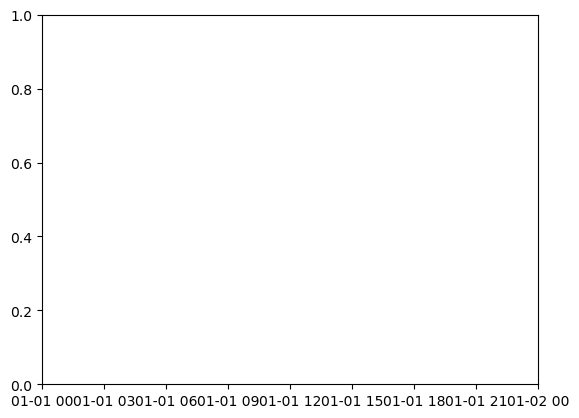

In [11]:
fs = 1.0
IG = (1/900, 1/25)
SS = (1/25, fs/2)

Hig2 = compute_hs(ds.p2[:,0], IG, fs)

plt.plot(ds.time[:,0], Hig2)

**3.** For each of the four sites using CMI.p*, **compute time series of Hss and Hig**.  For site 7, use CMI.e7 (surface-corrected pressure) instead of CMI.p7.  Plot the Hss (Figure 1) and Hig (Figure 2) time series.  